<a href="https://colab.research.google.com/github/cahecaz/TrabajoFinal_analisisdesentimientos/blob/main/Analisis_Inicial_IA_Tweets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo final: analizador de sentimientos

## Etapa 1. Carga y conocimiento del dataset

**Dataset:** IA Tweets Analysis Dataset (Spanish)  
**Fuente:** Zenodo, registro 10821485  
**Objetivo de esta etapa:** cargar una copia original y comprobar su estructura, tipos de datos, valores ausentes, duplicados y distribución de las etiquetas.

> En esta etapa no se modifican los datos originales.

In [1]:
# 1. Importar la biblioteca necesaria
import pandas as pd

In [2]:
# 2. Cargar el archivo CSV
# En Google Colab, primero se debe cargar ia_tweets.csv en Archivos.
ruta_archivo = 'https://raw.githubusercontent.com/cahecaz/TrabajoFinal_analisisdesentimientos/main/ia_tweets.csv'

datos = pd.read_csv(ruta_archivo)

In [3]:
# 3. Visualizar los primeros registros
datos.head()

,ID,text,polarity,favorite_count,retweet_count,user_followers_count,user_friends_count,user_favourites_count,user_statuses_count,user_verified,user_has_extended_profile,user_is_translator,user_protected,user_default_profile
0,0,Comentaba en una charla sobre IA que el proble...,N,21,7,15936,2395,66945,68578,0,1,0,0,0
1,1,"@alvaropons Eso es imposible. Y sí, va a gener...",N,1,0,685,851,169490,128555,0,1,0,0,1
2,2,@alvaropons Lo disruptivo es que tras años de ...,NEU,1,0,685,851,169490,128555,0,1,0,0,1
3,3,"@alvaropons ¿""Prohibición del uso comercial de...",N,0,0,4877,538,6123,3156,0,1,0,0,0
4,4,@santoroydonoso Cómo se está estudiando prohib...,NEU,0,0,15936,2395,66945,68578,0,1,0,0,0


In [4]:
# 4. Conocer la cantidad de filas y columnas
print('Filas:', datos.shape[0])
print('Columnas:', datos.shape[1])

Filas: 4038
Columnas: 14


In [5]:
# 5. Conocer las columnas y sus tipos de datos
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4038 entries, 0 to 4037
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         4038 non-null   int64 
 1   text                       4038 non-null   object
 2   polarity                   4038 non-null   object
 3   favorite_count             4038 non-null   int64 
 4   retweet_count              4038 non-null   int64 
 5   user_followers_count       4038 non-null   int64 
 6   user_friends_count         4038 non-null   int64 
 7   user_favourites_count      4038 non-null   int64 
 8   user_statuses_count        4038 non-null   int64 
 9   user_verified              4038 non-null   int64 
 10  user_has_extended_profile  4038 non-null   int64 
 11  user_is_translator         4038 non-null   int64 
 12  user_protected             4038 non-null   int64 
 13  user_default_profile       4038 non-null   int64 
dtypes: int64

In [6]:
# 6. Contabilizar valores ausentes
datos.isnull().sum()

,0
ID,0
text,0
polarity,0
favorite_count,0
retweet_count,0
user_followers_count,0
user_friends_count,0
user_favourites_count,0
user_statuses_count,0
user_verified,0


In [7]:
# 7. Contabilizar filas duplicadas y textos repetidos
print('Filas completamente duplicadas:', datos.duplicated().sum())
print('Textos repetidos:', datos['text'].duplicated().sum())

Filas completamente duplicadas: 0
Textos repetidos: 57


In [8]:
# 8. Examinar la distribución de las etiquetas
distribucion = datos['polarity'].value_counts()
distribucion

,count
polarity,
NEU,2689
P,757
N,592


In [9]:
# 9. Mostrar la distribución porcentual
porcentaje = datos['polarity'].value_counts(normalize=True).mul(100).round(2)
porcentaje

,proportion
polarity,
NEU,66.59
P,18.75
N,14.66


## Resultados comprobados

- El dataset contiene **4.038 registros y 14 columnas**.
- No presenta valores ausentes ni textos vacíos.
- Los 4.038 identificadores son únicos.
- No existen filas completamente duplicadas, pero hay **57 textos repetidos**.
- La distribución es: **2.689 neutros (66,59 %), 757 positivos (18,75 %) y 592 negativos (14,66 %)**.
- La clase neutra predomina, por lo que el desequilibrio deberá considerarse al dividir los datos y al interpretar precisión, recall y F1-score.
- La decisión sobre el tratamiento de los 57 textos repetidos se adoptará en la etapa de preparación, manteniendo intacto el archivo original.

## Sustento y referencias de esta etapa

La fuente original documenta la procedencia, estructura y uso previsto del dataset (Guerrero-Contreras et al., 2024a). El estudio asociado analiza sentimientos en redes sociales mediante texto y metadatos (Guerrero-Contreras et al., 2024b). Para el posterior análisis del rendimiento por clase se considera que una sola medida puede ocultar diferencias entre categorías, por lo que se conservarán precisión, recall y F1-score por clase (Sokolova & Lapalme, 2009).

### Referencias APA 7

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., & Muñoz, A. (2024a). *IA Tweets Analysis Dataset (Spanish)* (Version v1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.10821485

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., & Muñoz, A. (2024b). Enhancing sentiment analysis on social media: Integrating text and metadata for refined insights. En *2024 International Conference on Intelligent Environments (IE)* (pp. 62–69). IEEE. https://doi.org/10.1109/IE61493.2024.10599899

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

# Etapa 2. Preparación y limpieza de los textos

## Diagnóstico previo

Antes de modificar los textos, se examina la presencia de enlaces, menciones,
hashtags, saltos de línea y espacios repetidos. El texto original se conservará
en la columna `text`, mientras que las transformaciones posteriores se almacenarán en una nueva columna llamada `texto_limpio`.

In [10]:
# 10. Identificar elementos presentes antes de la limpieza

cantidad_registros = len(datos)

diagnostico_textos = pd.DataFrame({
    'Elemento': [
        'Enlaces',
        'Menciones',
        'Hashtags',
        'Saltos de línea',
        'Espacios repetidos'
    ],
    'Cantidad': [
        datos['text'].str.contains(
            r'https?://\S+|www\.\S+',
            regex=True,
            na=False
        ).sum(),

        datos['text'].str.contains(
            r'@\w+',
            regex=True,
            na=False
        ).sum(),

        datos['text'].str.contains(
            r'#\w+',
            regex=True,
            na=False
        ).sum(),

        datos['text'].str.contains(
            '\n',
            regex=False,
            na=False
        ).sum(),

        datos['text'].str.contains(
            r'\s{2,}',
            regex=True,
            na=False
        ).sum()
    ]
})

diagnostico_textos['Porcentaje'] = (
    diagnostico_textos['Cantidad']
    / cantidad_registros
    * 100
).round(2)

diagnostico_textos

,Elemento,Cantidad,Porcentaje
0,Enlaces,1308,32.39
1,Menciones,2104,52.11
2,Hashtags,616,15.26
3,Saltos de línea,1182,29.27
4,Espacios repetidos,1084,26.84


## Sustento académico de la etapa

El preprocesamiento puede modificar el rendimiento de un clasificador, por lo
que las transformaciones deben definirse según las características reales del
dataset. En textos procedentes de redes sociales, elementos como hashtags,
emojis y expresiones informales pueden contener información relevante para el
sentimiento. Por esta razón, primero se diagnostica su presencia y posteriormente
se determina su tratamiento.

### Referencias APA 7

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., y Muñoz, A.
(2024). Enhancing sentiment analysis on social media: Integrating text and
metadata for refined insights. En *2024 International Conference on Intelligent
Environments (IE)* (pp. 62–69). IEEE.
https://doi.org/10.1109/IE61493.2024.10599899

Krouska, A., Troussas, C., y Virvou, M. (2016). The effect of preprocessing
techniques on Twitter sentiment analysis. En *2016 7th International Conference
on Information, Intelligence, Systems & Applications (IISA)* (pp. 1–5). IEEE.
https://doi.org/10.1109/IISA.2016.7785373

Symeonidis, S., Effrosynidis, D., y Arampatzis, A. (2018). A comparative
evaluation of pre-processing techniques and their interactions for Twitter
sentiment analysis. *Expert Systems with Applications, 110*, 298–310.
https://doi.org/10.1016/j.eswa.2018.06.022

In [11]:
# 11. Crear y limpiar la columna de texto

# Conservar intacta la columna original
datos['texto_limpio'] = datos['text'].copy()

# Convertir el texto a minúsculas
datos['texto_limpio'] = datos['texto_limpio'].str.lower()

# Eliminar enlaces
datos['texto_limpio'] = datos['texto_limpio'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    regex=True
)

# Eliminar menciones
datos['texto_limpio'] = datos['texto_limpio'].str.replace(
    r'@\w+',
    '',
    regex=True
)

# Eliminar el signo #, conservando la palabra del hashtag
datos['texto_limpio'] = datos['texto_limpio'].str.replace(
    '#',
    '',
    regex=False
)

# Reemplazar saltos de línea y espacios repetidos
datos['texto_limpio'] = datos['texto_limpio'].str.replace(
    r'\s+',
    ' ',
    regex=True
)

# Eliminar espacios al comienzo y al final
datos['texto_limpio'] = datos['texto_limpio'].str.strip()

In [12]:
# 12. Comprobar el resultado de la limpieza

print(
    'Textos vacíos después de la limpieza:',
    datos['texto_limpio'].eq('').sum()
)

print(
    'Enlaces restantes:',
    datos['texto_limpio'].str.contains(
        r'https?://\S+|www\.\S+',
        regex=True,
        na=False
    ).sum()
)

print(
    'Menciones restantes:',
    datos['texto_limpio'].str.contains(
        r'@\w+',
        regex=True,
        na=False
    ).sum()
)

print(
    'Signos # restantes:',
    datos['texto_limpio'].str.contains(
        '#',
        regex=False,
        na=False
    ).sum()
)

print(
    'Saltos de línea restantes:',
    datos['texto_limpio'].str.contains(
        '\n',
        regex=False,
        na=False
    ).sum()
)

print(
    'Espacios repetidos restantes:',
    datos['texto_limpio'].str.contains(
        r'\s{2,}',
        regex=True,
        na=False
    ).sum()
)

print(
    'Textos repetidos después de la limpieza:',
    datos['texto_limpio'].duplicated().sum()
)

datos[['text', 'texto_limpio']].head(10)

Textos vacíos después de la limpieza: 52
Enlaces restantes: 0
Menciones restantes: 0
Signos # restantes: 0
Saltos de línea restantes: 0
Espacios repetidos restantes: 0
Textos repetidos después de la limpieza: 140


,text,texto_limpio
0,Comentaba en una charla sobre IA que el proble...,comentaba en una charla sobre ia que el proble...
1,"@alvaropons Eso es imposible. Y sí, va a gener...","eso es imposible. y sí, va a generar un montón..."
2,@alvaropons Lo disruptivo es que tras años de ...,lo disruptivo es que tras años de decir que la...
3,"@alvaropons ¿""Prohibición del uso comercial de...","¿""prohibición del uso comercial de las imágene..."
4,@santoroydonoso Cómo se está estudiando prohib...,cómo se está estudiando prohibir chatgpt en eu...
5,@santoroydonoso @alvaropons Mientras tanto en ...,mientras tanto en sadaic
6,Esta transición va a estar bien difícil... El ...,esta transición va a estar bien difícil... el ...
7,Va a costar mucho adaptarse a los nuevos cambi...,va a costar mucho adaptarse a los nuevos cambi...
8,8/ Conclusión: La inteligencia artificial ha l...,8/ conclusión: la inteligencia artificial ha l...
9,9/ ¿Te gustó este hilo? ¡Comparte y sígueme pa...,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...


In [13]:
# 13. Examinar textos vacíos y duplicados después de la limpieza

textos_vacios = datos[
    datos['texto_limpio'].eq('')
][['text', 'polarity', 'texto_limpio']]

textos_duplicados = datos[
    datos['texto_limpio'].duplicated(keep=False)
][['text', 'polarity', 'texto_limpio']].sort_values(
    by='texto_limpio'
)

# Identificar textos iguales con diferentes etiquetas
cantidad_etiquetas = textos_duplicados.groupby(
    'texto_limpio'
)['polarity'].nunique()

textos_con_conflicto = cantidad_etiquetas[
    cantidad_etiquetas > 1
]

print('Registros con texto vacío:', len(textos_vacios))

print(
    'Registros involucrados en duplicados:',
    len(textos_duplicados)
)

print(
    'Textos duplicados con etiquetas diferentes:',
    len(textos_con_conflicto)
)

print('\nEjemplos de textos originales que quedaron vacíos:')
display(textos_vacios.head(10))

print('\nEjemplos de textos repetidos después de la limpieza:')
display(textos_duplicados.head(20))

Registros con texto vacío: 52
Registros involucrados en duplicados: 174
Textos duplicados con etiquetas diferentes: 1

Ejemplos de textos originales que quedaron vacíos:


,text,polarity,texto_limpio
110,@Chuskitin https://t.co/PBfWvTNlXr,NEU,
131,@lem_antonieta,NEU,
308,@EdelbertoJose https://t.co/OW2lqPz1UC,NEU,
318,@LeonKrauze @nytimes https://t.co/xVfL4eTxo0,NEU,
389,@Mariaporia @MJDuzan https://t.co/WAvpP6Vt8e,NEU,
476,@isabel_iglesias https://t.co/JfR45iKlCB,NEU,
568,@LaBrujulaXR,NEU,
645,@_d3lm0nt https://t.co/ewQQ84hVW3,NEU,
740,@RTVCComunica @SergioMiro https://t.co/u6krqhO...,NEU,
818,@AnimeLtd @f3_kenshin https://t.co/I9l736ll8s,NEU,



Ejemplos de textos repetidos después de la limpieza:


,text,polarity,texto_limpio
1362,@elpais_tec https://t.co/174AyIvavP,NEU,
1178,@carlotagalvan @Unancorcom https://t.co/TEcV1x...,NEU,
1218,@RosanaFerrero https://t.co/brHsjo2ufm,NEU,
1219,@RosanaFerrero https://t.co/eWw4Zvw0AB,NEU,
1329,@alba_delcampo https://t.co/eSwHpofjNK,NEU,
3731,@ViajesDigitales @lasseweb20 https://t.co/MDKF...,NEU,
1377,@marcsabaletee https://t.co/aL1mxBT8rQ,NEU,
3495,@beincrypto_es https://t.co/Sg6FiGcCAL,NEU,
2002,@ivandmattar https://t.co/47ucvQTnxI,NEU,
1446,@Tomi_dep @SoyReyMidas https://t.co/CYfYSvfTql,NEU,


In [14]:
# 14. Separar los textos vacíos y examinar el conflicto de etiquetas

# Distribución de las etiquetas de los textos vacíos
print('Etiquetas de los textos vacíos:')
print(textos_vacios['polarity'].value_counts())

# Crear una selección temporal sin textos vacíos
datos_no_vacios = datos[
    datos['texto_limpio'].ne('')
].copy()

print(
    '\nRegistros disponibles después de excluir los vacíos:',
    len(datos_no_vacios)
)

print(
    'Duplicados adicionales sin considerar los vacíos:',
    datos_no_vacios['texto_limpio'].duplicated().sum()
)

print(
    'Registros involucrados en duplicados no vacíos:',
    datos_no_vacios['texto_limpio'].duplicated(
        keep=False
    ).sum()
)

# Mostrar el texto duplicado que posee etiquetas diferentes
registros_con_conflicto = datos_no_vacios[
    datos_no_vacios['texto_limpio'].isin(
        textos_con_conflicto.index
    )
][['text', 'polarity', 'texto_limpio']]

print('\nTexto duplicado con etiquetas diferentes:')
display(registros_con_conflicto)

Etiquetas de los textos vacíos:
polarity
NEU    52
Name: count, dtype: int64

Registros disponibles después de excluir los vacíos: 3986
Duplicados adicionales sin considerar los vacíos: 89
Registros involucrados en duplicados no vacíos: 122

Texto duplicado con etiquetas diferentes:


,text,polarity,texto_limpio
1052,@aalbaperez Totalmente de acuerdo,P,totalmente de acuerdo
2072,@mjmolano @almaldo2 Totalmente de acuerdo,NEU,totalmente de acuerdo
2882,@DrNickolaz Totalmente de acuerdo,P,totalmente de acuerdo
3590,@rforcano Totalmente de acuerdo,P,totalmente de acuerdo


In [15]:
# 15. Crear el conjunto de datos limpio

# Identificar textos repetidos con etiquetas diferentes
cantidad_etiquetas = datos_no_vacios.groupby(
    'texto_limpio'
)['polarity'].nunique()

textos_conflictivos = cantidad_etiquetas[
    cantidad_etiquetas > 1
].index

# Excluir los textos con etiquetas contradictorias
datos_limpios = datos_no_vacios[
    ~datos_no_vacios['texto_limpio'].isin(
        textos_conflictivos
    )
].copy()

# Conservar una sola aparición de cada texto repetido
datos_limpios = datos_limpios.drop_duplicates(
    subset='texto_limpio',
    keep='first'
)

# Reorganizar el índice
datos_limpios = datos_limpios.reset_index(drop=True)

print('Registros originales:', len(datos))
print('Registros del conjunto limpio:', len(datos_limpios))
print('Registros excluidos:', len(datos) - len(datos_limpios))

print(
    'Textos vacíos restantes:',
    datos_limpios['texto_limpio'].eq('').sum()
)

print(
    'Textos duplicados restantes:',
    datos_limpios['texto_limpio'].duplicated().sum()
)

print('\nDistribución final de sentimientos:')
print(datos_limpios['polarity'].value_counts())

datos_limpios[['text', 'texto_limpio', 'polarity']].head(10)

Registros originales: 4038
Registros del conjunto limpio: 3896
Registros excluidos: 142
Textos vacíos restantes: 0
Textos duplicados restantes: 0

Distribución final de sentimientos:
polarity
NEU    2608
P       700
N       588
Name: count, dtype: int64


,text,texto_limpio,polarity
0,Comentaba en una charla sobre IA que el proble...,comentaba en una charla sobre ia que el proble...,N
1,"@alvaropons Eso es imposible. Y sí, va a gener...","eso es imposible. y sí, va a generar un montón...",N
2,@alvaropons Lo disruptivo es que tras años de ...,lo disruptivo es que tras años de decir que la...,NEU
3,"@alvaropons ¿""Prohibición del uso comercial de...","¿""prohibición del uso comercial de las imágene...",N
4,@santoroydonoso Cómo se está estudiando prohib...,cómo se está estudiando prohibir chatgpt en eu...,NEU
5,@santoroydonoso @alvaropons Mientras tanto en ...,mientras tanto en sadaic,NEU
6,Esta transición va a estar bien difícil... El ...,esta transición va a estar bien difícil... el ...,N
7,Va a costar mucho adaptarse a los nuevos cambi...,va a costar mucho adaptarse a los nuevos cambi...,N
8,8/ Conclusión: La inteligencia artificial ha l...,8/ conclusión: la inteligencia artificial ha l...,P
9,9/ ¿Te gustó este hilo? ¡Comparte y sígueme pa...,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,P


## Conclusión de la limpieza

El proceso de limpieza generó un conjunto de 3.896 registros utilizables. Se
excluyeron 142 registros, equivalentes al 3,52 % del dataset original.

La exclusión consideró textos que quedaron vacíos después de retirar enlaces y
menciones, duplicados generados o identificados durante la normalización y un
texto repetido que presentaba etiquetas de sentimiento contradictorias.

La columna `text` conserva el contenido original, mientras que `texto_limpio`
contiene la versión preparada para las siguientes etapas. El conjunto final no
presenta textos vacíos ni duplicados.

La categoría neutra continúa siendo predominante, con el 66,94 % de los
registros. Esta distribución deberá considerarse posteriormente al dividir los
datos y al interpretar las métricas del clasificador.

# Etapa 3. Tokenización

La tokenización divide cada texto limpio en unidades más pequeñas denominadas
tokens. Debido a que los datos proceden de Twitter, se utiliza `TweetTokenizer`
de NLTK, herramienta diseñada para trabajar con características frecuentes de
las redes sociales.

En esta etapa solamente se generan los tokens. Su contenido será examinado antes
de retirar signos de puntuación u otros elementos.

In [16]:
# 16. Tokenizar los textos con NLTK

from nltk.tokenize import TweetTokenizer

tokenizador = TweetTokenizer()

datos_limpios['tokens'] = datos_limpios[
    'texto_limpio'
].apply(tokenizador.tokenize)

datos_limpios[
    ['texto_limpio', 'tokens', 'polarity']
].head(10)

,texto_limpio,tokens,polarity
0,comentaba en una charla sobre ia que el proble...,"[comentaba, en, una, charla, sobre, ia, que, e...",N
1,"eso es imposible. y sí, va a generar un montón...","[eso, es, imposible, ., y, sí, ,, va, a, gener...",N
2,lo disruptivo es que tras años de decir que la...,"[lo, disruptivo, es, que, tras, años, de, deci...",NEU
3,"¿""prohibición del uso comercial de las imágene...","[¿, "", prohibición, del, uso, comercial, de, l...",N
4,cómo se está estudiando prohibir chatgpt en eu...,"[cómo, se, está, estudiando, prohibir, chatgpt...",NEU
5,mientras tanto en sadaic,"[mientras, tanto, en, sadaic]",NEU
6,esta transición va a estar bien difícil... el ...,"[esta, transición, va, a, estar, bien, difícil...",N
7,va a costar mucho adaptarse a los nuevos cambi...,"[va, a, costar, mucho, adaptarse, a, los, nuev...",N
8,8/ conclusión: la inteligencia artificial ha l...,"[8/, conclusión, :, la, inteligencia, artifici...",P
9,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,"[9, /, ¿, te, gustó, este, hilo, ?, ¡, compart...",P


In [17]:
# 17. Comprobar el resultado de la tokenización

datos_limpios['cantidad_tokens'] = datos_limpios[
    'tokens'
].apply(len)

print(
    'Registros sin tokens:',
    datos_limpios['cantidad_tokens'].eq(0).sum()
)

print(
    'Cantidad mínima de tokens:',
    datos_limpios['cantidad_tokens'].min()
)

print(
    'Cantidad máxima de tokens:',
    datos_limpios['cantidad_tokens'].max()
)

print(
    'Promedio de tokens por texto:',
    round(datos_limpios['cantidad_tokens'].mean(), 2)
)

datos_limpios[
    ['texto_limpio', 'tokens', 'cantidad_tokens']
].head(10)

Registros sin tokens: 0
Cantidad mínima de tokens: 1
Cantidad máxima de tokens: 71
Promedio de tokens por texto: 30.39


,texto_limpio,tokens,cantidad_tokens
0,comentaba en una charla sobre ia que el proble...,"[comentaba, en, una, charla, sobre, ia, que, e...",46
1,"eso es imposible. y sí, va a generar un montón...","[eso, es, imposible, ., y, sí, ,, va, a, gener...",45
2,lo disruptivo es que tras años de decir que la...,"[lo, disruptivo, es, que, tras, años, de, deci...",39
3,"¿""prohibición del uso comercial de las imágene...","[¿, "", prohibición, del, uso, comercial, de, l...",21
4,cómo se está estudiando prohibir chatgpt en eu...,"[cómo, se, está, estudiando, prohibir, chatgpt...",43
5,mientras tanto en sadaic,"[mientras, tanto, en, sadaic]",4
6,esta transición va a estar bien difícil... el ...,"[esta, transición, va, a, estar, bien, difícil...",49
7,va a costar mucho adaptarse a los nuevos cambi...,"[va, a, costar, mucho, adaptarse, a, los, nuev...",33
8,8/ conclusión: la inteligencia artificial ha l...,"[8/, conclusión, :, la, inteligencia, artifici...",40
9,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,"[9, /, ¿, te, gustó, este, hilo, ?, ¡, compart...",22


## Conclusión de la tokenización

La tokenización se aplicó a los 3.896 textos mediante `TweetTokenizer` de NLTK.
Todos los registros generaron al menos un token, por lo que no se detectaron
textos inutilizables durante esta etapa.

La cantidad de tokens varía entre 1 y 71, con un promedio de 30,39 tokens por
texto. Los signos de puntuación fueron reconocidos como tokens independientes,
lo cual corresponde al funcionamiento del tokenizador y no representa un error.

La columna `texto_limpio` permanece disponible, mientras que la nueva columna
`tokens` conserva el resultado de la segmentación para las etapas posteriores.

### Referencias APA 7

Bird, S., Klein, E., y Loper, E. (2009). *Natural language processing with
Python*. O'Reilly Media.

Camacho-Collados, J., y Pilehvar, M. T. (2018). On the role of text
preprocessing in neural network architectures: An evaluation study on text
categorization and sentiment analysis. En *Proceedings of the 2018 EMNLP
Workshop BlackboxNLP* (pp. 40–46).
https://doi.org/10.18653/v1/W18-5406

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., y Muñoz, A.
(2024). Enhancing sentiment analysis on social media: Integrating text and
metadata for refined insights. En *2024 International Conference on Intelligent
Environments (IE)* (pp. 62–69). IEEE.
https://doi.org/10.1109/IE61493.2024.10599899

# Etapa 4. Lematización

La lematización transforma las palabras flexionadas en su forma base o lema.
Por ejemplo, formas como `trabajando`, `trabajó` y `trabajan` pueden relacionarse
con el lema `trabajar`.

Para procesar los textos en español se utiliza spaCy con el modelo
`es_core_news_sm`. Durante esta etapa se retiran los tokens correspondientes a
espacios y signos de puntuación, pero se conservan las palabras frecuentes,
las negaciones y los emojis.

In [18]:
# 18. Instalar el modelo de spaCy para español

!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 54.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [19]:
# 19. Cargar spaCy y el modelo en español

import spacy

nlp = spacy.load('es_core_news_sm')

print('Modelo de español cargado correctamente')

Modelo de español cargado correctamente


In [20]:
# 20. Lematizar los textos

def lematizar_texto(texto):

    documento = nlp(texto)

    lemas = [
        token.lemma_
        for token in documento
        if not token.is_space
        and not token.is_punct
    ]

    return lemas


datos_limpios['lemas'] = datos_limpios[
    'texto_limpio'
].apply(lematizar_texto)

datos_limpios[
    ['texto_limpio', 'tokens', 'lemas', 'polarity']
].head(10)

,texto_limpio,tokens,lemas,polarity
0,comentaba en una charla sobre ia que el proble...,"[comentaba, en, una, charla, sobre, ia, que, e...","[comentar, en, uno, charla, sobre, ia, que, el...",N
1,"eso es imposible. y sí, va a generar un montón...","[eso, es, imposible, ., y, sí, ,, va, a, gener...","[ese, ser, imposible, y, sí, ir, a, generar, u...",N
2,lo disruptivo es que tras años de decir que la...,"[lo, disruptivo, es, que, tras, años, de, deci...","[él, disruptivo, ser, que, tras, año, de, deci...",NEU
3,"¿""prohibición del uso comercial de las imágene...","[¿, "", prohibición, del, uso, comercial, de, l...","[prohibición, del, uso, comercial, de, el, ima...",N
4,cómo se está estudiando prohibir chatgpt en eu...,"[cómo, se, está, estudiando, prohibir, chatgpt...","[cómo, él, estar, estudiar, prohibir, chatgpt,...",NEU
5,mientras tanto en sadaic,"[mientras, tanto, en, sadaic]","[mientras, tanto, en, sadaic]",NEU
6,esta transición va a estar bien difícil... el ...,"[esta, transición, va, a, estar, bien, difícil...","[este, transición, ir, a, estar, bien, difícil...",N
7,va a costar mucho adaptarse a los nuevos cambi...,"[va, a, costar, mucho, adaptarse, a, los, nuev...","[ir, a, costar, mucho, adaptar él, a, el, nuev...",N
8,8/ conclusión: la inteligencia artificial ha l...,"[8/, conclusión, :, la, inteligencia, artifici...","[8/, conclusión, el, inteligencia, artificial,...",P
9,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,"[9, /, ¿, te, gustó, este, hilo, ?, ¡, compart...","[9/, tú, gustar, este, hilo, comparte, y, sígu...",P


In [21]:
# 21. Comprobar el resultado de la lematización

# Unir los lemas para formar un texto procesado
datos_limpios['texto_lematizado'] = datos_limpios[
    'lemas'
].apply(' '.join)

# Contabilizar los lemas de cada registro
datos_limpios['cantidad_lemas'] = datos_limpios[
    'lemas'
].apply(len)

print(
    'Registros sin lemas:',
    datos_limpios['cantidad_lemas'].eq(0).sum()
)

print(
    'Cantidad mínima de lemas:',
    datos_limpios['cantidad_lemas'].min()
)

print(
    'Cantidad máxima de lemas:',
    datos_limpios['cantidad_lemas'].max()
)

print(
    'Promedio de lemas por texto:',
    round(datos_limpios['cantidad_lemas'].mean(), 2)
)

print(
    'Textos repetidos después de lematizar:',
    datos_limpios['texto_lematizado'].duplicated().sum()
)

# Comprobar posibles duplicados con etiquetas diferentes
etiquetas_por_texto = datos_limpios.groupby(
    'texto_lematizado'
)['polarity'].nunique()

print(
    'Textos lematizados con etiquetas diferentes:',
    etiquetas_por_texto.gt(1).sum()
)

datos_limpios[
    [
        'texto_limpio',
        'texto_lematizado',
        'cantidad_lemas',
        'polarity'
    ]
].head(10)

Registros sin lemas: 2
Cantidad mínima de lemas: 0
Cantidad máxima de lemas: 61
Promedio de lemas por texto: 26.81
Textos repetidos después de lematizar: 11
Textos lematizados con etiquetas diferentes: 3


,texto_limpio,texto_lematizado,cantidad_lemas,polarity
0,comentaba en una charla sobre ia que el proble...,comentar en uno charla sobre ia que el problem...,43,N
1,"eso es imposible. y sí, va a generar un montón...",ese ser imposible y sí ir a generar uno montón...,40,N
2,lo disruptivo es que tras años de decir que la...,él disruptivo ser que tras año de decir que el...,38,NEU
3,"¿""prohibición del uso comercial de las imágene...",prohibición del uso comercial de el imagen ia ...,16,N
4,cómo se está estudiando prohibir chatgpt en eu...,cómo él estar estudiar prohibir chatgpt en eur...,38,NEU
5,mientras tanto en sadaic,mientras tanto en sadaic,4,NEU
6,esta transición va a estar bien difícil... el ...,este transición ir a estar bien difícil el pla...,39,N
7,va a costar mucho adaptarse a los nuevos cambi...,ir a costar mucho adaptar él a el nuevo cambio...,27,N
8,8/ conclusión: la inteligencia artificial ha l...,8/ conclusión el inteligencia artificial haber...,36,P
9,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,9/ tú gustar este hilo comparte y síguemir par...,17,P


In [22]:
# 22. Examinar casos generados por la lematización

registros_sin_lemas = datos_limpios[
    datos_limpios['cantidad_lemas'].eq(0)
][
    ['text', 'texto_limpio', 'polarity']
]

duplicados_lematizados = datos_limpios[
    datos_limpios['texto_lematizado'].duplicated(
        keep=False
    )
][
    [
        'text',
        'texto_limpio',
        'texto_lematizado',
        'polarity'
    ]
].sort_values(
    by='texto_lematizado'
)

textos_lematizados_conflictivos = etiquetas_por_texto[
    etiquetas_por_texto > 1
].index

registros_lematizados_conflictivos = datos_limpios[
    datos_limpios['texto_lematizado'].isin(
        textos_lematizados_conflictivos
    )
][
    [
        'text',
        'texto_limpio',
        'texto_lematizado',
        'polarity'
    ]
].sort_values(
    by='texto_lematizado'
)

print(
    'Registros sin lemas:',
    len(registros_sin_lemas)
)

print(
    'Registros involucrados en duplicados:',
    len(duplicados_lematizados)
)

print(
    'Grupos con etiquetas diferentes:',
    len(textos_lematizados_conflictivos)
)

print('\nRegistros sin lemas:')
display(registros_sin_lemas)

print('\nDuplicados con etiquetas diferentes:')
display(registros_lematizados_conflictivos)

Registros sin lemas: 2
Registros involucrados en duplicados: 20
Grupos con etiquetas diferentes: 3

Registros sin lemas:


,text,texto_limpio,polarity
231,@carlesplb @PalomaLLaneza @lopalasi @sailormer...,",",NEU
2441,...@JuanLozano_R @lcvelez \n@Enrique_GomezM\n@...,...,NEU



Duplicados con etiquetas diferentes:


,text,texto_limpio,texto_lematizado,polarity
1249,@Juan_Salvador_G @Canal22 Gracias!,gracias!,gracias,P
3516,@ConCienciaUSAC ¡Gracias!,¡gracias!,gracias,P
3852,@JuanDGut Gracias,gracias,gracias,NEU
670,@davidtomas @la_informacion Gracias David !,gracias david !,gracias david,P
807,@jorgedalv Gracias David.,gracias david.,gracias david,NEU
2502,@fdopena @alvarogcl Muchas gracias.,muchas gracias.,mucho gracia,NEU
3845,@angelcaido666x Muchas gracias,muchas gracias,mucho gracia,P


In [23]:
# 23. Crear el conjunto final después de la lematización

# Excluir registros sin lemas
datos_lematizados = datos_limpios[
    datos_limpios['cantidad_lemas'].gt(0)
].copy()

# Excluir textos lematizados con etiquetas contradictorias
datos_lematizados = datos_lematizados[
    ~datos_lematizados['texto_lematizado'].isin(
        textos_lematizados_conflictivos
    )
].copy()

# Conservar una sola aparición de los duplicados consistentes
datos_lematizados = datos_lematizados.drop_duplicates(
    subset='texto_lematizado',
    keep='first'
)

# Reorganizar el índice
datos_lematizados = datos_lematizados.reset_index(
    drop=True
)

print(
    'Registros antes del control:',
    len(datos_limpios)
)

print(
    'Registros finales:',
    len(datos_lematizados)
)

print(
    'Registros excluidos en esta etapa:',
    len(datos_limpios) - len(datos_lematizados)
)

print(
    'Registros sin lemas restantes:',
    datos_lematizados['cantidad_lemas'].eq(0).sum()
)

print(
    'Duplicados restantes:',
    datos_lematizados[
        'texto_lematizado'
    ].duplicated().sum()
)

etiquetas_finales = datos_lematizados.groupby(
    'texto_lematizado'
)['polarity'].nunique()

print(
    'Conflictos de etiquetas restantes:',
    etiquetas_finales.gt(1).sum()
)

print('\nDistribución final:')
print(datos_lematizados['polarity'].value_counts())

datos_lematizados[
    [
        'texto_limpio',
        'texto_lematizado',
        'polarity'
    ]
].head(10)

Registros antes del control: 3896
Registros finales: 3881
Registros excluidos en esta etapa: 15
Registros sin lemas restantes: 0
Duplicados restantes: 0
Conflictos de etiquetas restantes: 0

Distribución final:
polarity
NEU    2598
P       696
N       587
Name: count, dtype: int64


,texto_limpio,texto_lematizado,polarity
0,comentaba en una charla sobre ia que el proble...,comentar en uno charla sobre ia que el problem...,N
1,"eso es imposible. y sí, va a generar un montón...",ese ser imposible y sí ir a generar uno montón...,N
2,lo disruptivo es que tras años de decir que la...,él disruptivo ser que tras año de decir que el...,NEU
3,"¿""prohibición del uso comercial de las imágene...",prohibición del uso comercial de el imagen ia ...,N
4,cómo se está estudiando prohibir chatgpt en eu...,cómo él estar estudiar prohibir chatgpt en eur...,NEU
5,mientras tanto en sadaic,mientras tanto en sadaic,NEU
6,esta transición va a estar bien difícil... el ...,este transición ir a estar bien difícil el pla...,N
7,va a costar mucho adaptarse a los nuevos cambi...,ir a costar mucho adaptar él a el nuevo cambio...,N
8,8/ conclusión: la inteligencia artificial ha l...,8/ conclusión el inteligencia artificial haber...,P
9,9/ ¿te gustó este hilo? ¡comparte y sígueme pa...,9/ tú gustar este hilo comparte y síguemir par...,P


## Conclusión de la lematización

La lematización se aplicó mediante spaCy y su modelo para español a los 3.896
registros procedentes de la etapa anterior.

Durante la validación se identificaron dos registros sin lemas, once duplicados
generados por la normalización lingüística y tres grupos de textos con etiquetas
contradictorias. Estos casos fueron tratados sin modificar las etiquetas
originales.

El conjunto resultante contiene 3.881 registros, sin textos vacíos, duplicados
ni conflictos de etiquetas. La clase neutra continúa siendo mayoritaria, con
el 66,94 % de los registros.

La lematización automática también produjo algunas construcciones lingüísticas
imperfectas. Esta situación se conservará como una limitación del procesamiento,
ya que no corresponde modificar manualmente los resultados del modelo.

### Referencias APA 7

Camacho-Collados, J., y Pilehvar, M. T. (2018). On the role of text
preprocessing in neural network architectures: An evaluation study on text
categorization and sentiment analysis. En *Proceedings of the 2018 EMNLP
Workshop BlackboxNLP* (pp. 40–46).
https://doi.org/10.18653/v1/W18-5406

Honnibal, M., Montani, I., Van Landeghem, S., y Boyd, A. (2020).
*spaCy: Industrial-strength natural language processing in Python*.
Zenodo. https://doi.org/10.5281/zenodo.1212303

Symeonidis, S., Effrosynidis, D., y Arampatzis, A. (2018). A comparative
evaluation of pre-processing techniques and their interactions for Twitter
sentiment analysis. *Expert Systems with Applications, 110*, 298–310.
https://doi.org/10.1016/j.eswa.2018.06.022

# Etapa 5. Desarrollo del analizador de sentimientos

Se desarrolla un clasificador supervisado utilizando los textos lematizados y
las etiquetas originales del dataset.

Los datos se dividen en un 80 % para entrenamiento y un 20 % para prueba. La
división es estratificada para conservar la proporción de las categorías
negativa, neutra y positiva.

Los textos se representan numéricamente mediante TF-IDF y posteriormente se
entrena un modelo de regresión logística. En esta primera versión no se aplican
técnicas de balanceo ni optimización, porque se busca obtener un resultado base
que permita evaluar el comportamiento inicial del analizador.

In [24]:
# 24. Dividir los datos en entrenamiento y prueba

from sklearn.model_selection import train_test_split

X = datos_lematizados['texto_lematizado']
y = datos_lematizados['polarity']

X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    'Registros de entrenamiento:',
    len(X_entrenamiento)
)

print(
    'Registros de prueba:',
    len(X_prueba)
)

print('\nDistribución en entrenamiento:')
print(y_entrenamiento.value_counts())

print('\nDistribución en prueba:')
print(y_prueba.value_counts())

Registros de entrenamiento: 3104
Registros de prueba: 777

Distribución en entrenamiento:
polarity
NEU    2078
P       557
N       469
Name: count, dtype: int64

Distribución en prueba:
polarity
NEU    520
P      139
N      118
Name: count, dtype: int64


In [25]:
# 25. Convertir los textos en variables numéricas

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer()

X_entrenamiento_tfidf = vectorizador.fit_transform(
    X_entrenamiento
)

X_prueba_tfidf = vectorizador.transform(
    X_prueba
)

print(
    'Dimensión de entrenamiento:',
    X_entrenamiento_tfidf.shape
)

print(
    'Dimensión de prueba:',
    X_prueba_tfidf.shape
)

print(
    'Cantidad de términos aprendidos:',
    len(vectorizador.get_feature_names_out())
)

Dimensión de entrenamiento: (3104, 8737)
Dimensión de prueba: (777, 8737)
Cantidad de términos aprendidos: 8737


In [26]:
# 26. Entrenar el analizador de sentimientos

from sklearn.linear_model import LogisticRegression

analizador = LogisticRegression(
    max_iter=1000,
    random_state=42
)

analizador.fit(
    X_entrenamiento_tfidf,
    y_entrenamiento
)

print('Analizador entrenado correctamente')
print('Categorías aprendidas:', analizador.classes_)

Analizador entrenado correctamente
Categorías aprendidas: ['N' 'NEU' 'P']


## Conclusión del desarrollo del analizador

El conjunto de 3.881 registros fue dividido de manera estratificada en 3.104
registros de entrenamiento y 777 registros de prueba, correspondientes
aproximadamente al 80 % y 20 %, respectivamente.

La estratificación permitió mantener proporciones similares de las categorías
negativa, neutra y positiva en ambos conjuntos.

El vectorizador TF-IDF fue ajustado exclusivamente con los textos de
entrenamiento e identificó 8.737 términos. Posteriormente, los textos de prueba
fueron transformados utilizando el mismo vocabulario, evitando incorporar
información anticipada del conjunto de evaluación.

Finalmente, se entrenó un modelo de regresión logística que reconoció las tres
categorías previstas: negativa (`N`), neutra (`NEU`) y positiva (`P`). Esta
primera versión constituye un modelo base, sin balanceo ni optimización de
parámetros.

### Referencias APA 7

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., y Muñoz, A.
(2024). Enhancing sentiment analysis on social media: Integrating text and
metadata for refined insights. En *2024 International Conference on Intelligent
Environments (IE)* (pp. 62–69). IEEE.
https://doi.org/10.1109/IE61493.2024.10599899

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Salton, G., y Buckley, C. (1988). Term-weighting approaches in automatic text
retrieval. *Information Processing & Management, 24*(5), 513–523.
https://doi.org/10.1016/0306-4573(88)90021-0

# Etapa 6. Clasificación de sentimientos

El analizador entrenado se aplica a los 777 registros reservados para prueba.
Para cada texto se conserva la etiqueta real del dataset y se incorpora la
categoría predicha por el modelo.

Las etiquetas se presentan con sus nombres completos:

- `N`: Negativo.
- `NEU`: Neutro.
- `P`: Positivo.

En esta etapa solamente se generan y organizan las predicciones. La comparación
del desempeño se realizará posteriormente.

In [27]:
# 27. Clasificar los textos del conjunto de prueba

predicciones = analizador.predict(
    X_prueba_tfidf
)

print(
    'Predicciones generadas:',
    len(predicciones)
)

print(
    'Categorías predichas:',
    sorted(set(predicciones))
)

Predicciones generadas: 777
Categorías predichas: ['N', 'NEU', 'P']


In [28]:
# 28. Crear la tabla de resultados

resultados = datos_lematizados.loc[
    X_prueba.index,
    [
        'text',
        'texto_limpio',
        'texto_lematizado',
        'polarity'
    ]
].copy()

resultados = resultados.rename(
    columns={
        'polarity': 'sentimiento_real_codigo'
    }
)

resultados[
    'sentimiento_predicho_codigo'
] = predicciones

nombres_sentimientos = {
    'N': 'Negativo',
    'NEU': 'Neutro',
    'P': 'Positivo'
}

resultados['sentimiento_real'] = resultados[
    'sentimiento_real_codigo'
].map(nombres_sentimientos)

resultados['sentimiento_predicho'] = resultados[
    'sentimiento_predicho_codigo'
].map(nombres_sentimientos)

resultados = resultados.reset_index(drop=True)

resultados[
    [
        'text',
        'sentimiento_real',
        'sentimiento_predicho'
    ]
].head(20)

,text,sentimiento_real,sentimiento_predicho
0,@itskatty_v_v weeeeey,Neutro,Neutro
1,Para mí que le han preguntado al propio chat l...,Neutro,Neutro
2,A OpenAI se le ha otorgado tiempo adicional pa...,Neutro,Neutro
3,@ANGESC7MMedios Ok pues esas tareas de medició...,Positivo,Neutro
4,@ikerlafuente_ Yo hable con Messi de esa forma...,Neutro,Neutro
5,Esas preguntas y más fueron parte de los temas...,Neutro,Neutro
6,@carmenbeat Yo me preguntaba como definiría lo...,Neutro,Neutro
7,@JacoboFeijo Evidentemente. A ver si te cree q...,Neutro,Neutro
8,"A este respecto, Lanier cree que TikTok deberí...",Negativo,Neutro
9,Estamos comprimiendo los ciclos de innovación ...,Positivo,Neutro


In [29]:
# 29. Comprobar el resultado de la clasificación

print(
    'Cantidad de resultados:',
    len(resultados)
)

print(
    'Predicciones vacías:',
    resultados[
        'sentimiento_predicho'
    ].isnull().sum()
)

print('\nDistribución de sentimientos reales:')
print(
    resultados[
        'sentimiento_real'
    ].value_counts()
)

print('\nDistribución de sentimientos predichos:')
print(
    resultados[
        'sentimiento_predicho'
    ].value_counts()
)

Cantidad de resultados: 777
Predicciones vacías: 0

Distribución de sentimientos reales:
sentimiento_real
Neutro      520
Positivo    139
Negativo    118
Name: count, dtype: int64

Distribución de sentimientos predichos:
sentimiento_predicho
Neutro      724
Positivo     34
Negativo     19
Name: count, dtype: int64


## Conclusión de la clasificación

El analizador generó una predicción para cada uno de los 777 registros del
conjunto de prueba. No se identificaron valores vacíos y el modelo utilizó las
tres categorías previstas: negativa, neutra y positiva.

La distribución de las predicciones difiere de la distribución real. Mientras
el 66,92 % de los textos está etiquetado originalmente como neutro, el modelo
clasificó el 93,18 % en esa categoría.

Por su parte, las predicciones positivas representaron el 4,38 % y las negativas
el 2,45 %, porcentajes inferiores a sus proporciones reales. Este resultado
sugiere preliminarmente una tendencia del modelo hacia la clase mayoritaria.

Esta observación todavía no constituye una evaluación definitiva. En las
siguientes etapas se compararán las etiquetas reales y predichas y se calcularán
precisión, recall y F1-score para cada categoría.

### Referencias APA 7

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., y Muñoz, A.
(2024). Enhancing sentiment analysis on social media: Integrating text and
metadata for refined insights. En *2024 International Conference on Intelligent
Environments (IE)* (pp. 62–69). IEEE.
https://doi.org/10.1109/IE61493.2024.10599899

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

# Etapa 7. Comparación entre sentimientos reales y predichos

Las etiquetas entregadas por el dataset se comparan individualmente con las
categorías generadas por el analizador.

Se identifica si cada predicción coincide o no con su etiqueta real. También
se construye una tabla cruzada para observar hacia qué categoría fueron
clasificados los textos negativos, neutros y positivos.

Esta comparación constituye una descripción inicial de los resultados. Las
métricas específicas se calcularán en las etapas siguientes.

In [30]:
# 30. Comparar las etiquetas reales y predichas

resultados['coincide'] = (
    resultados['sentimiento_real_codigo']
    ==
    resultados['sentimiento_predicho_codigo']
)

resultados['resultado_comparacion'] = resultados[
    'coincide'
].map({
    True: 'Coincide',
    False: 'No coincide'
})

cantidad_coincidencias = resultados[
    'coincide'
].sum()

cantidad_errores = (
    len(resultados)
    -
    cantidad_coincidencias
)

porcentaje_coincidencia = (
    cantidad_coincidencias
    /
    len(resultados)
    *
    100
)

print(
    'Cantidad de coincidencias:',
    cantidad_coincidencias
)

print(
    'Cantidad de errores:',
    cantidad_errores
)

print(
    'Porcentaje de coincidencia:',
    round(porcentaje_coincidencia, 2),
    '%'
)

Cantidad de coincidencias: 549
Cantidad de errores: 228
Porcentaje de coincidencia: 70.66 %


In [31]:
# 31. Comparar las categorías reales y predichas

tabla_comparacion = pd.crosstab(
    resultados['sentimiento_real'],
    resultados['sentimiento_predicho'],
    rownames=['Sentimiento real'],
    colnames=['Sentimiento predicho'],
    margins=True,
    margins_name='Total'
)

tabla_comparacion

Sentimiento predicho,Negativo,Neutro,Positivo,Total
Sentimiento real,,,,
Negativo,12,106,0,118
Neutro,5,509,6,520
Positivo,2,109,28,139
Total,19,724,34,777


In [32]:
# 32. Mostrar ejemplos de clasificaciones incorrectas

errores_clasificacion = resultados[
    ~resultados['coincide']
][
    [
        'text',
        'texto_lematizado',
        'sentimiento_real',
        'sentimiento_predicho'
    ]
]

print(
    'Errores disponibles:',
    len(errores_clasificacion)
)

errores_clasificacion.head(20)

Errores disponibles: 228


,text,texto_lematizado,sentimiento_real,sentimiento_predicho
3,@ANGESC7MMedios Ok pues esas tareas de medició...,ok pues ese tarea de medición ser esencial,Positivo,Neutro
8,"A este respecto, Lanier cree que TikTok deberí...",a este respecto lanier creer que tiktok deber ...,Negativo,Neutro
9,Estamos comprimiendo los ciclos de innovación ...,estar comprimeir el ciclo de innovación de año...,Positivo,Neutro
12,@BirmajerOk La estupidez humana entrego la nac...,el estupidez humano entrego el nación al kirch...,Negativo,Neutro
16,@eelua @AEPD_es Claro: un sistema 🇪🇦 dónde los...,claro uno sistema 🇪 🇦 dónde el elector no eleg...,Negativo,Neutro
20,"🧠 #ChatGPT ayudó a #Vitalik Buterin, cofundado...",🧠 chatgpt ayudar a vitalik buterin cofundador ...,Positivo,Neutro
21,Esto permite a las empresas tomar medidas prev...,este permitir a el empresa tomar medida preven...,Positivo,Neutro
28,Si quieres estar al día de las últimas novedad...,si querer estar al día de el último novedad en...,Positivo,Neutro
35,"🔁 CJ. @NicolasMaduro\n""Con Maduro +"" llegó par...",🔁 cj con maduro + llegar para acompañar al pue...,Positivo,Neutro
41,Una mujer identificada como Jennifer DeStefano...,uno mujer identificado como jennifer destefano...,Negativo,Neutro


## Conclusión de la comparación

El analizador coincidió con la etiqueta real en 549 de los 777 registros,
alcanzando un porcentaje general de coincidencia del 70,66 %. Los 228 registros
restantes, equivalentes al 29,34 %, fueron clasificados incorrectamente.

La tabla comparativa muestra diferencias importantes entre las categorías. El
modelo identificó correctamente 509 de los 520 textos neutros. Sin embargo,
106 de los 118 textos negativos y 109 de los 139 positivos fueron clasificados
como neutros.

En total, 215 de los 228 errores consistieron en desplazar textos positivos o
negativos hacia la categoría neutra. Esto equivale al 94,30 % de los errores
observados y confirma una concentración del modelo en la clase mayoritaria.

Por tanto, el porcentaje general de coincidencia debe interpretarse con
precaución. Un resultado global aparentemente favorable puede ocultar un
desempeño insuficiente en las categorías minoritarias. Esta situación será
examinada mediante precisión, recall y F1-score.

### Referencias APA 7

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to
ROC, informedness, markedness and correlation. *Journal of Machine Learning
Technologies, 2*(1), 37–63.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

# Etapa 8. Precisión del analizador

La precisión indica la proporción de predicciones correctas entre todos los
registros clasificados por el modelo dentro de una categoría.

Se calcula la precisión individual de las categorías negativa, neutra y
positiva. Además, se obtienen los promedios macro y ponderado.

El promedio macro asigna la misma importancia a las tres categorías. El promedio
ponderado considera la cantidad real de registros pertenecientes a cada clase.

In [33]:
# 33. Calcular la precisión por categoría

from sklearn.metrics import precision_score

codigos_categorias = ['N', 'NEU', 'P']

precision_categorias = precision_score(
    y_prueba,
    predicciones,
    labels=codigos_categorias,
    average=None,
    zero_division=0
)

tabla_precision = pd.DataFrame({
    'Código': codigos_categorias,
    'Sentimiento': [
        'Negativo',
        'Neutro',
        'Positivo'
    ],
    'Precisión': precision_categorias
})

tabla_precision['Precisión (%)'] = (
    tabla_precision['Precisión']
    *
    100
).round(2)

tabla_precision

,Código,Sentimiento,Precisión,Precisión (%)
0,N,Negativo,0.631579,63.16
1,NEU,Neutro,0.703039,70.30
2,P,Positivo,0.823529,82.35


In [34]:
# 34. Calcular la precisión macro y ponderada

precision_macro = precision_score(
    y_prueba,
    predicciones,
    average='macro',
    zero_division=0
)

precision_ponderada = precision_score(
    y_prueba,
    predicciones,
    average='weighted',
    zero_division=0
)

print(
    'Precisión macro:',
    round(precision_macro, 4)
)

print(
    'Precisión macro (%):',
    round(precision_macro * 100, 2)
)

print(
    'Precisión ponderada:',
    round(precision_ponderada, 4)
)

print(
    'Precisión ponderada (%):',
    round(precision_ponderada * 100, 2)
)

Precisión macro: 0.7194
Precisión macro (%): 71.94
Precisión ponderada: 0.7137
Precisión ponderada (%): 71.37


## Conclusión de la precisión

La categoría positiva obtuvo la mayor precisión, con un 82,35 %. Esto significa
que 28 de las 34 predicciones positivas coincidieron con la etiqueta real.

La categoría neutra alcanzó una precisión del 70,30 %, correspondiente a 509
aciertos entre 724 predicciones. La categoría negativa presentó el resultado
más bajo, con un 63,16 %, al registrar 12 aciertos entre 19 predicciones.

La precisión macro fue de 71,94 %, mientras que la precisión ponderada alcanzó
71,37 %. La proximidad entre ambos promedios muestra que las diferencias de
precisión entre las categorías no son extremas.

Sin embargo, la precisión no permite determinar cuántos textos positivos o
negativos reales fueron identificados. Una categoría puede presentar una
precisión alta a partir de pocas predicciones. Por ello, el resultado deberá
complementarse con el recall.

### Referencias APA 7

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to
ROC, informedness, markedness and correlation. *Journal of Machine Learning
Technologies, 2*(1), 37–63.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

# Etapa 9. Recall del analizador

El recall mide la capacidad del modelo para identificar los registros que
realmente pertenecen a una categoría.

Se calcula el recall para los sentimientos negativo, neutro y positivo. También
se obtienen los promedios macro y ponderado.

El promedio macro asigna la misma importancia a cada categoría, mientras que el
promedio ponderado considera la cantidad de registros reales de cada clase.

In [35]:
# 35. Calcular el recall por categoría

from sklearn.metrics import recall_score

recall_categorias = recall_score(
    y_prueba,
    predicciones,
    labels=codigos_categorias,
    average=None,
    zero_division=0
)

tabla_recall = pd.DataFrame({
    'Código': codigos_categorias,
    'Sentimiento': [
        'Negativo',
        'Neutro',
        'Positivo'
    ],
    'Recall': recall_categorias
})

tabla_recall['Recall (%)'] = (
    tabla_recall['Recall']
    *
    100
).round(2)

tabla_recall

,Código,Sentimiento,Recall,Recall (%)
0,N,Negativo,0.101695,10.17
1,NEU,Neutro,0.978846,97.88
2,P,Positivo,0.201439,20.14


In [36]:
# 36. Calcular el recall macro y ponderado

recall_macro = recall_score(
    y_prueba,
    predicciones,
    average='macro',
    zero_division=0
)

recall_ponderado = recall_score(
    y_prueba,
    predicciones,
    average='weighted',
    zero_division=0
)

print(
    'Recall macro:',
    round(recall_macro, 4)
)

print(
    'Recall macro (%):',
    round(recall_macro * 100, 2)
)

print(
    'Recall ponderado:',
    round(recall_ponderado, 4)
)

print(
    'Recall ponderado (%):',
    round(recall_ponderado * 100, 2)
)

Recall macro: 0.4273
Recall macro (%): 42.73
Recall ponderado: 0.7066
Recall ponderado (%): 70.66


## Conclusión del recall

El modelo alcanzó un recall del 97,88 % para la categoría neutra, identificando
correctamente 509 de los 520 registros neutros.

El desempeño fue considerablemente menor en las categorías minoritarias. El
recall negativo fue de 10,17 %, con 12 aciertos entre 118 casos reales, mientras
que el recall positivo alcanzó 20,14 %, con 28 aciertos entre 139 registros.

El recall macro fue de 42,73 %, lo que evidencia que el modelo no mantiene un
rendimiento equilibrado entre las tres categorías. El recall ponderado alcanzó
70,66 %, resultado influido por la mayor cantidad de textos neutros.

Por tanto, aunque el modelo presenta una alta capacidad para reconocer la clase
neutra, pierde una proporción importante de los sentimientos positivos y
negativos.

### Referencias APA 7

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to
ROC, informedness, markedness and correlation. *Journal of Machine Learning
Technologies, 2*(1), 37–63.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

# Etapa 10. F1-score del analizador

El F1-score combina precisión y recall mediante su media armónica. Esta métrica
permite evaluar conjuntamente qué tan confiables son las predicciones y cuántos
casos reales logra recuperar el modelo.

Se calcula el F1-score por categoría y mediante los promedios macro y ponderado.

In [37]:
# 37. Calcular el F1-score por categoría

from sklearn.metrics import f1_score

f1_categorias = f1_score(
    y_prueba,
    predicciones,
    labels=codigos_categorias,
    average=None,
    zero_division=0
)

tabla_f1 = pd.DataFrame({
    'Código': codigos_categorias,
    'Sentimiento': [
        'Negativo',
        'Neutro',
        'Positivo'
    ],
    'F1-score': f1_categorias
})

tabla_f1['F1-score (%)'] = (
    tabla_f1['F1-score']
    *
    100
).round(2)

tabla_f1

,Código,Sentimiento,F1-score,F1-score (%)
0,N,Negativo,0.175182,17.52
1,NEU,Neutro,0.818328,81.83
2,P,Positivo,0.323699,32.37


In [38]:
# 38. Calcular el F1-score macro y ponderado

f1_macro = f1_score(
    y_prueba,
    predicciones,
    average='macro',
    zero_division=0
)

f1_ponderado = f1_score(
    y_prueba,
    predicciones,
    average='weighted',
    zero_division=0
)

print(
    'F1-score macro:',
    round(f1_macro, 4)
)

print(
    'F1-score macro (%):',
    round(f1_macro * 100, 2)
)

print(
    'F1-score ponderado:',
    round(f1_ponderado, 4)
)

print(
    'F1-score ponderado (%):',
    round(f1_ponderado * 100, 2)
)

F1-score macro: 0.4391
F1-score macro (%): 43.91
F1-score ponderado: 0.6322
F1-score ponderado (%): 63.22


## Conclusión del F1-score

El F1-score confirmó diferencias importantes en el desempeño del analizador
entre las tres categorías.

La categoría neutra alcanzó el resultado más alto, con un F1-score de 81,83 %,
debido a la combinación de una precisión de 70,30 % y un recall de 97,88 %.

La categoría positiva obtuvo un F1-score de 32,37 %. Aunque presentó una
precisión de 82,35 %, solamente logró recuperar el 20,14 % de los textos
positivos reales.

La categoría negativa presentó el resultado más bajo, con un F1-score de
17,52 %. Su precisión fue de 63,16 %, pero su recall alcanzó solo el 10,17 %.

El F1-score macro fue de 43,91 %, evidenciando un rendimiento desigual cuando
las tres categorías reciben la misma importancia. El F1-score ponderado fue de
63,22 %, resultado influido por el predominio y el mejor reconocimiento de la
categoría neutra.

En consecuencia, el analizador constituye una primera versión funcional, pero
su capacidad para distinguir sentimientos positivos y negativos es limitada.
El rendimiento observado debe interpretarse considerando el desequilibrio del
dataset y la tendencia del modelo a clasificar los textos como neutros.

### Referencias APA 7

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to
ROC, informedness, markedness and correlation. *Journal of Machine Learning
Technologies, 2*(1), 37–63.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

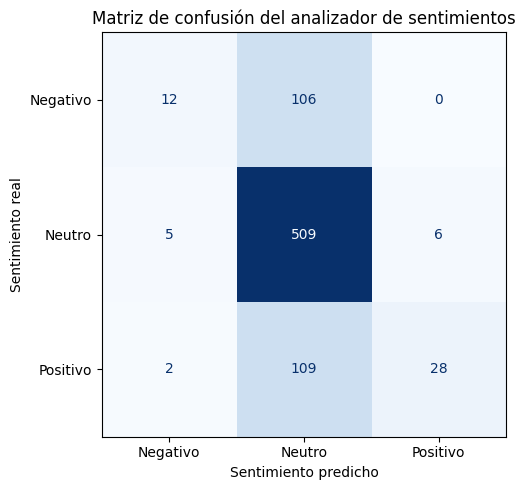

In [39]:
# 39. Elaborar la matriz de confusión

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

codigos_matriz = ['N', 'NEU', 'P']

nombres_matriz = [
    'Negativo',
    'Neutro',
    'Positivo'
]

matriz_confusion = confusion_matrix(
    y_prueba,
    predicciones,
    labels=codigos_matriz
)

figura, eje = plt.subplots(
    figsize=(7, 5)
)

visualizacion = ConfusionMatrixDisplay(
    confusion_matrix=matriz_confusion,
    display_labels=nombres_matriz
)

visualizacion.plot(
    ax=eje,
    cmap='Blues',
    values_format='d',
    colorbar=False
)

plt.title(
    'Matriz de confusión del analizador de sentimientos'
)

plt.xlabel('Sentimiento predicho')
plt.ylabel('Sentimiento real')
plt.tight_layout()
plt.show()

In [40]:
# 40. Comprobar los valores de la matriz

tabla_matriz = pd.DataFrame(
    matriz_confusion,
    index=[
        'Real: Negativo',
        'Real: Neutro',
        'Real: Positivo'
    ],
    columns=[
        'Predicho: Negativo',
        'Predicho: Neutro',
        'Predicho: Positivo'
    ]
)

print(
    'Total de registros representados:',
    matriz_confusion.sum()
)

print('\nTotales por sentimiento real:')
print(
    tabla_matriz.sum(axis=1)
)

print('\nTotales por sentimiento predicho:')
print(
    tabla_matriz.sum(axis=0)
)

tabla_matriz

Total de registros representados: 777

Totales por sentimiento real:
Real: Negativo    118
Real: Neutro      520
Real: Positivo    139
dtype: int64

Totales por sentimiento predicho:
Predicho: Negativo     19
Predicho: Neutro      724
Predicho: Positivo     34
dtype: int64


,Predicho: Negativo,Predicho: Neutro,Predicho: Positivo
Real: Negativo,12,106,0
Real: Neutro,5,509,6
Real: Positivo,2,109,28


## Conclusión de la matriz de confusión

La matriz de confusión representa los 777 registros del conjunto de prueba y
confirma los resultados obtenidos previamente. La diagonal contiene 549
clasificaciones correctas, mientras que los valores fuera de ella reúnen 228
errores.

El modelo identificó correctamente 509 textos neutros, 28 positivos y 12
negativos. Su principal dificultad se encuentra en la diferenciación de las
categorías minoritarias: 106 textos negativos y 109 positivos fueron
clasificados como neutros.

En total, 215 errores se concentran en el desplazamiento de textos positivos o
negativos hacia la categoría neutra. La intensidad visual de la columna central
refleja esta tendencia y evidencia la influencia del desequilibrio existente en
los datos.

La figura también muestra que no existieron textos negativos clasificados como
positivos. Sin embargo, este resultado no compensa la baja capacidad del modelo
para recuperar las categorías positiva y negativa.

### Referencias APA 7

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J.,
Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011).
Scikit-learn: Machine learning in Python. *Journal of Machine Learning
Research, 12*, 2825–2830.

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to
ROC, informedness, markedness and correlation. *Journal of Machine Learning
Technologies, 2*(1), 37–63.

Sokolova, M., y Lapalme, G. (2009). A systematic analysis of performance
measures for classification tasks. *Information Processing & Management,
45*(4), 427–437.
https://doi.org/10.1016/j.ipm.2009.03.002

In [41]:
# 41. Interpretación de los resultados
# Analizar la dirección de los errores de clasificación

errores_clasificacion = resultados[
    resultados["sentimiento_real"] != resultados["sentimiento_predicho"]
].copy()

tabla_errores = (
    errores_clasificacion
    .groupby(["sentimiento_real", "sentimiento_predicho"])
    .size()
    .reset_index(name="cantidad")
    .sort_values("cantidad", ascending=False)
)

tabla_errores["porcentaje_sobre_errores"] = (
    tabla_errores["cantidad"]
    / len(errores_clasificacion)
    * 100
).round(2)

# Errores positivos o negativos clasificados como neutros
errores_hacia_neutro = errores_clasificacion[
    (errores_clasificacion["sentimiento_real"].isin(["Positivo", "Negativo"]))
    & (errores_clasificacion["sentimiento_predicho"] == "Neutro")
]

print("Total de registros evaluados:", len(resultados))
print("Predicciones correctas:", (resultados["sentimiento_real"] == resultados["sentimiento_predicho"]).sum())
print("Errores de clasificación:", len(errores_clasificacion))

print("\nErrores positivos o negativos clasificados como neutros:")
print(len(errores_hacia_neutro))

print(
    "Porcentaje que representan sobre todos los errores:",
    round(len(errores_hacia_neutro) / len(errores_clasificacion) * 100, 2),
    "%"
)

print("\nDirección de los errores:")
display(tabla_errores)

Total de registros evaluados: 777
Predicciones correctas: 549
Errores de clasificación: 228

Errores positivos o negativos clasificados como neutros:
215
Porcentaje que representan sobre todos los errores: 94.3 %

Dirección de los errores:


,sentimiento_real,sentimiento_predicho,cantidad,porcentaje_sobre_errores
4,Positivo,Neutro,109,47.81
0,Negativo,Neutro,106,46.49
2,Neutro,Positivo,6,2.63
1,Neutro,Negativo,5,2.19
3,Positivo,Negativo,2,0.88


## Interpretación de los resultados

El analizador clasificó correctamente 549 de los 777 registros del conjunto de prueba, alcanzando una exactitud general de 70,66 %. Sin embargo, este resultado debe analizarse junto con las métricas obtenidas para cada categoría, debido a que la distribución de los sentimientos no es equilibrada.

La categoría neutra presentó el mejor desempeño, con una precisión de 70,30 %, un recall de 97,88 % y un F1-score de 81,83 %. Esto indica que el modelo identificó prácticamente todos los comentarios realmente neutros. No obstante, también mostró una marcada tendencia a utilizar esta categoría: 724 de las 777 predicciones fueron clasificadas como neutras.

Las categorías negativa y positiva obtuvieron precisiones de 63,16 % y 82,35 %, respectivamente. Sin embargo, sus valores de recall fueron considerablemente menores: 10,17 % para los comentarios negativos y 20,14 % para los positivos. Por consiguiente, cuando el modelo predice estas categorías suele alcanzar una precisión aceptable, pero deja sin identificar una proporción importante de los textos que realmente pertenecen a ellas.

El análisis de los errores confirma esta tendencia. De los 228 errores de clasificación, 106 comentarios negativos y 109 positivos fueron clasificados como neutros. En conjunto, estos 215 casos representan el 94,30 % de todos los errores. Por tanto, la principal dificultad del modelo no consiste en confundir directamente los sentimientos positivos con los negativos, sino en desplazar ambas categorías hacia la clase neutra.

La diferencia entre el F1-score ponderado de 63,22 % y el F1-score macro de 43,91 % también evidencia un desempeño desigual entre las categorías. La medida ponderada está influida por la mayor cantidad de textos neutros, mientras que la medida macro asigna la misma importancia a las tres clases y refleja con mayor claridad el bajo desempeño alcanzado en las categorías positiva y negativa.

Este comportamiento es consistente con el desbalance observado en los datos de entrenamiento, donde la categoría neutra contiene una cantidad considerablemente mayor de registros. Sin embargo, el desbalance no constituye por sí solo una explicación definitiva. También podrían influir la brevedad y ambigüedad de los mensajes, el lenguaje informal, la pérdida de contexto provocada por la eliminación de menciones y enlaces, y las limitaciones de la lematización automática.

En conclusión, el analizador cumple con la clasificación solicitada en categorías positiva, negativa y neutra y proporciona una línea base reproducible. No obstante, su rendimiento general está sostenido principalmente por la categoría neutra. En consecuencia, la exactitud de 70,66 % no debe interpretarse de manera aislada, pues el recall y el F1-score por categoría muestran que todavía existen dificultades relevantes para reconocer sentimientos positivos y negativos.

### Referencias

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering, 21*(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation. *Journal of Machine Learning Technologies, 2*(1), 37–63.

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

## Evaluación del contexto, objetivo y actores involucrados

### Contexto

El proyecto se desarrolla en el ámbito del análisis automatizado de opiniones expresadas en redes sociales. Estas plataformas generan grandes cantidades de textos breves, informales y dependientes del contexto, lo que dificulta su clasificación manual. Para abordar este problema se utilizó el conjunto público *IA Tweets Analysis Dataset (Spanish)*, compuesto por publicaciones en español relacionadas con la inteligencia artificial.

El análisis de sentimientos permite organizar estas opiniones en categorías positivas, negativas y neutras. Esta información puede facilitar el estudio de percepciones colectivas, tendencias de opinión y reacciones frente a temas tecnológicos.

### Objetivo

El objetivo fue desarrollar un analizador de sentimientos capaz de clasificar automáticamente comentarios en español como positivos, negativos o neutros. Para ello se aplicó un proceso reproducible que incluyó carga y exploración de los datos, limpieza de textos, tokenización, lematización, representación mediante TF-IDF y entrenamiento de un modelo de regresión logística.

El objetivo técnico fue cumplido, debido a que el modelo genera las tres categorías solicitadas y permite evaluar sus predicciones mediante exactitud, precisión, recall, F1-score y matriz de confusión. Sin embargo, los resultados muestran que su capacidad para reconocer sentimientos positivos y negativos todavía es limitada.

### Actores involucrados

Los principales actores relacionados con el proyecto son:

- **Usuarios de redes sociales:** generan los comentarios y opiniones que componen los datos analizados.
- **Investigadores responsables del dataset:** recopilan, organizan, documentan y publican los datos.
- **Analistas y desarrolladores:** preparan los textos, construyen el modelo y evalúan sus resultados.
- **Organizaciones e instituciones:** podrían utilizar este tipo de análisis para conocer percepciones sobre productos, servicios, políticas, tecnologías o temas de interés público.
- **Responsables de tomar decisiones:** utilizan los resultados como información complementaria, considerando las limitaciones y los posibles errores del modelo.

El uso de publicaciones provenientes de redes sociales requiere resguardar la privacidad, evitar la identificación innecesaria de sus autores y reconocer que una clasificación automática no representa completamente la intención o el contexto de cada persona.

### Aporte innovador

El aporte del proyecto no consiste en crear un algoritmo completamente nuevo, sino en integrar técnicas de procesamiento del lenguaje natural y aprendizaje automático en un flujo de trabajo reproducible, desarrollado con herramientas gratuitas y aplicado a textos reales en español sobre inteligencia artificial.

La innovación se encuentra en transformar datos textuales no estructurados en información cuantificable y evaluable. Además, el análisis separado por categorías permitió detectar que la exactitud general oculta dificultades importantes para reconocer comentarios positivos y negativos. Esta observación aporta una base concreta para futuras mejoras del modelo y demuestra la importancia de interpretar los resultados más allá de una única métrica.

### Evaluación general

El proyecto responde al contexto planteado y cumple su objetivo funcional, pues permite clasificar comentarios en las tres categorías requeridas. También identifica a los actores que producen, procesan y utilizan la información. No obstante, cualquier aplicación práctica debe considerar el desbalance de las categorías, las limitaciones del lenguaje utilizado en redes sociales y la tendencia observada del modelo a clasificar los comentarios como neutros.

## Reflexiones sobre el trabajo realizado

### Reflexión 1. La exactitud general no representa todo el desempeño del modelo

Una de las principales reflexiones obtenidas es que la exactitud general no debe utilizarse de manera aislada para evaluar un clasificador. Aunque el analizador alcanzó una exactitud de 70,66 %, el análisis por categorías mostró un recall de solo 10,17 % para los comentarios negativos y de 20,14 % para los positivos.

Esta diferencia demuestra que un resultado general aparentemente favorable puede ocultar dificultades importantes. Por esta razón, fue necesario complementar la exactitud con la precisión, el recall, el F1-score y la matriz de confusión.

### Reflexión 2. La calidad y distribución de los datos influyen en los resultados

El desarrollo del proyecto permitió comprender que el rendimiento de un modelo depende tanto del algoritmo utilizado como de las características de los datos. La mayor presencia de comentarios neutros en el conjunto de entrenamiento es consistente con la tendencia del modelo a clasificar la mayoría de los textos dentro de esa categoría.

Asimismo, las decisiones adoptadas durante la limpieza, tokenización y lematización pueden modificar la información disponible para el aprendizaje. La eliminación de enlaces y menciones fue necesaria para reducir elementos que no aportaban contenido textual directo, pero también pudo eliminar parte del contexto original de algunos mensajes.

### Reflexión 3. El lenguaje expresado en redes sociales representa un desafío

Los comentarios publicados en redes sociales suelen contener abreviaciones, errores ortográficos, ironías, símbolos, emojis y expresiones dependientes del contexto. Estas características dificultan que un modelo basado en términos identifique correctamente la intención de cada mensaje.

El trabajo permitió reconocer que clasificar sentimientos no consiste únicamente en buscar palabras positivas o negativas. La interpretación también puede depender del contexto, del orden de las palabras y de información que no siempre está presente en el texto procesado.

### Reflexión 4. La clasificación automática requiere interpretación y supervisión humana

El analizador permite procesar una cantidad de comentarios mayor que la que podría examinarse manualmente en el mismo tiempo. Sin embargo, sus predicciones no deben considerarse decisiones definitivas, especialmente cuando se utilizan en contextos institucionales o para conocer opiniones de personas.

Los resultados deben interpretarse como información de apoyo. La supervisión humana continúa siendo necesaria para analizar casos ambiguos, reconocer posibles errores y evitar conclusiones que no estén respaldadas por las métricas obtenidas.

### Reflexión final

El desarrollo de este proyecto permitió integrar conocimientos de procesamiento del lenguaje natural, preparación de datos y evaluación de modelos. También fortaleció la capacidad de interpretar resultados de manera crítica y de reconocer que el valor de una solución de inteligencia artificial no depende solamente de que funcione técnicamente, sino también de que sus resultados sean explicables, reproducibles y utilizados de manera responsable.

## Sustento académico y referencias

El conjunto de datos empleado fue publicado por Guerrero-Contreras et al. (2024) para apoyar investigaciones relacionadas con el análisis de sentimientos en publicaciones en español sobre inteligencia artificial.

La implementación del analizador se realizó mediante herramientas de *scikit-learn*, biblioteca que integra métodos de aprendizaje automático supervisado y no supervisado en Python (Pedregosa et al., 2011).

La evaluación se efectuó mediante exactitud, precisión, recall, F1-score y matriz de confusión. Estas métricas permiten examinar el rendimiento general y las diferencias existentes entre las categorías de un problema de clasificación (Powers, 2011; Sokolova & Lapalme, 2009).

El desbalance entre las categorías debe considerarse al interpretar los resultados, debido a que una clase mayoritaria puede influir en el comportamiento del modelo y ocultar un desempeño reducido en las clases menos representadas (He & Garcia, 2009).

### Referencias

Guerrero-Contreras, G., Balderas-Díaz, S., Serrano-Fernández, A., & Muñoz, A. (2024). *IA Tweets Analysis Dataset (Spanish)* (Version v1) [Conjunto de datos]. Zenodo. https://doi.org/10.5281/zenodo.10821485

He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering, 21*(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html

Powers, D. M. W. (2011). Evaluation: From precision, recall and F-measure to ROC, informedness, markedness and correlation. *Journal of Machine Learning Technologies, 2*(1), 37–63.

Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management, 45*(4), 427–437. https://doi.org/10.1016/j.ipm.2009.03.002

In [43]:
# 46. Comprobación final de la ejecución

comprobaciones = {
    "Dataset original cargado": "datos" in globals(),
    "Datos limpios disponibles": "datos_limpios" in globals(),
    "Datos lematizados disponibles": "datos_lematizados" in globals(),
    "Analizador entrenado": "analizador" in globals(),
    "Predicciones generadas": "predicciones" in globals(),
    "Resultados disponibles": "resultados" in globals(),
    "Cantidad de registros evaluados correcta": (
        "resultados" in globals() and len(resultados) == 777
    ),
    "Predicciones sin valores vacíos": (
        "resultados" in globals()
        and resultados["sentimiento_predicho"].isna().sum() == 0
    ),
    "Tres categorías generadas": (
        "resultados" in globals()
        and set(resultados["sentimiento_predicho"].unique())
        == {"Negativo", "Neutro", "Positivo"}
    )
}

for comprobacion, resultado in comprobaciones.items():
    estado = "CORRECTO" if resultado else "PENDIENTE"
    print(f"{estado}: {comprobacion}")

if all(comprobaciones.values()):
    print("\nCOMPROBACIÓN FINAL: todas las condiciones se cumplen.")
else:
    print("\nCOMPROBACIÓN FINAL: existen condiciones pendientes.")

CORRECTO: Dataset original cargado
CORRECTO: Datos limpios disponibles
CORRECTO: Datos lematizados disponibles
CORRECTO: Analizador entrenado
CORRECTO: Predicciones generadas
CORRECTO: Resultados disponibles
CORRECTO: Cantidad de registros evaluados correcta
CORRECTO: Predicciones sin valores vacíos
CORRECTO: Tres categorías generadas

COMPROBACIÓN FINAL: todas las condiciones se cumplen.
